# Predicting Child Malnutrition Hotspots in Cameroon
### CEC 420 - Data Mining
**Author:** SEPO PERRY-BRADLEY DINGA (CT23A145)
**Department:** Computer Engineering - Software Engineering
**Academic Year:** 2025 / 2026

End-to-end analysis of child stunting rates across Cameroon's 10 admin-1 regions using five DHS survey rounds (1991–2018). Follows the **CRISP-DM** framework: business understanding → data understanding → data preparation → modelling → evaluation → deployment.

## 0. Setup

In [1]:
# Make the project root importable
import sys, os
from pathlib import Path
ROOT = Path(os.getcwd()).resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
print("Project root:", ROOT)

Project root: C:\Users\USER\Desktop\All\data420


## 1. Business Understanding

Roughly 29% of Cameroonian children under five are stunted, but the burden is uneven across regions. The goal is to build a regression model that predicts a region's stunting rate from socio-economic indicators, then rank regions by predicted risk to guide nutrition and WASH interventions.

## 2. Data Understanding

The dataset combines five Cameroon DHS/MICS survey rounds (1991, 1998, 2004, 2011, 2018) across 10 admin-1 regions, giving **50 observations**. Key indicators cover maternal education, WASH access, healthcare delivery, and disease burden. The target variable is `stunting_rate` (% of children under-5 who are stunted).

In [2]:
from src import preprocessing
df = preprocessing.load_or_build()
print(f"Analysis table shape: {df.shape}")
df.head()

Analysis table shape: (1040, 27)


,year,region,antenatal_4plus_pct,antenatal_skilled_pct,child_anemia_pct,fertility_rate,health_facility_delivery_pct,improved_sanitation_pct,improved_water_pct,malaria_prevalence_pct,skilled_birth_attendance_pct,stunting_rate,underweight_pct,wasting_pct,women_literate_pct,women_secondary_plus_pct,health_insurance_any_pct,breakdown_dim,breakdown_value,subregion,data_source,maternal_education_years,wealth_index,poverty_headcount_pct,facilities_per_10k,population_density,urban_share_pct
0,1991,Adamawa,24.400000,53.100000,62.3,6.40,32.000000,4.20,42.4,27.35,33.300000,39.70,25.50,9.30,77.3,40.6,1.5,Region,Adamawa,Adamawa,real_dhs,NaN,NaN,NaN,NaN,NaN,NaN
1,1991,Centre,60.700000,92.866667,62.3,5.35,77.650000,13.20,54.8,27.35,79.116667,22.35,6.75,1.70,77.3,40.6,1.5,Region,Centre,Centre,real_dhs,NaN,NaN,NaN,NaN,NaN,NaN
2,1991,East,45.900000,86.466667,62.3,6.30,59.733333,2.50,25.3,27.35,61.900000,30.80,10.30,2.60,77.3,40.6,1.5,Region,East,East,real_dhs,NaN,NaN,NaN,NaN,NaN,NaN
3,1991,Far North,24.400000,53.100000,62.3,6.40,32.000000,4.20,42.4,27.35,33.300000,39.70,25.50,9.30,77.3,40.6,1.5,Region,Far North,Far North,real_dhs,NaN,NaN,NaN,NaN,NaN,NaN
4,1991,Littoral,70.083333,95.833333,62.3,5.20,88.950000,14.25,61.8,27.35,90.266667,22.25,4.40,1.15,77.3,40.6,1.5,Region,Littoral,Littoral,real_dhs,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          1040 non-null   int64  
 1   region                        1040 non-null   str    
 2   antenatal_4plus_pct           1040 non-null   float64
 3   antenatal_skilled_pct         1040 non-null   float64
 4   child_anemia_pct              1040 non-null   float64
 5   fertility_rate                1040 non-null   float64
 6   health_facility_delivery_pct  1040 non-null   float64
 7   improved_sanitation_pct       1040 non-null   float64
 8   improved_water_pct            1040 non-null   float64
 9   malaria_prevalence_pct        1040 non-null   float64
 10  skilled_birth_attendance_pct  1040 non-null   float64
 11  stunting_rate                 1040 non-null   float64
 12  underweight_pct               1040 non-null   float64
 13  wasting_pct   

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,1040.0,2007.031731,13.348514,1985.000000,1998.000000,2007.000000,2018.000000,2030.000000
antenatal_4plus_pct,1040.0,44.529712,26.333256,5.000000,21.000000,47.000000,64.541667,98.000000
antenatal_skilled_pct,1040.0,90.490729,5.479629,50.950000,91.366667,91.366667,91.366667,100.000000
child_anemia_pct,1040.0,57.127115,9.343557,29.600000,50.700000,57.800000,62.725000,84.900000
fertility_rate,1040.0,5.862721,1.363389,2.360000,4.912500,5.880000,6.990000,8.000000
health_facility_delivery_pct,1040.0,72.271603,8.828707,16.533333,73.300000,73.300000,73.300000,99.800000
improved_sanitation_pct,1040.0,34.839111,21.844304,0.000000,16.900000,35.650000,51.050000,97.200000
improved_water_pct,1040.0,56.434471,18.566253,10.000000,42.475000,55.900000,69.600000,99.000000
malaria_prevalence_pct,1040.0,29.019663,9.840439,4.300000,22.900000,27.350000,34.825000,59.100000
skilled_birth_attendance_pct,1040.0,44.937853,32.379993,5.000000,7.750000,44.300000,75.325000,99.466667


## 3. Data Preparation

Raw DHS CSVs are cleaned, de-duplicated, and imputed (region-year median, falling back to global median). Percentage columns are clipped to [0, 100]. Four composite scores are also computed (WASH composite, maternal health score, education score, disease burden) to reduce dimensionality for modelling.

In [5]:
from src.features import add_engineered, feature_matrix
df_eng = add_engineered(df)
X, y = feature_matrix(df)
print("X shape:", X.shape, "| y shape:", y.shape)
X.head()

X shape: (1040, 18) | y shape: (1040,)


,women_secondary_plus_pct,women_literate_pct,improved_water_pct,improved_sanitation_pct,antenatal_4plus_pct,antenatal_skilled_pct,skilled_birth_attendance_pct,health_facility_delivery_pct,health_insurance_any_pct,malaria_prevalence_pct,child_anemia_pct,wasting_pct,underweight_pct,fertility_rate,wash_composite,maternal_health_score,education_score,disease_burden
0,40.6,77.3,42.4,4.20,24.400000,53.100000,33.300000,32.000000,1.5,27.35,62.3,9.30,25.50,6.40,23.300,24.134615,58.95,44.825
1,40.6,77.3,54.8,13.20,60.700000,92.866667,79.116667,77.650000,1.5,27.35,62.3,1.70,6.75,5.35,34.000,80.641026,58.95,44.825
2,40.6,77.3,25.3,2.50,45.900000,86.466667,61.900000,59.733333,1.5,27.35,62.3,2.60,10.30,6.30,13.900,38.108974,58.95,44.825
3,40.6,77.3,42.4,4.20,24.400000,53.100000,33.300000,32.000000,1.5,27.35,62.3,9.30,25.50,6.40,23.300,24.134615,58.95,44.825
4,40.6,77.3,61.8,14.25,70.083333,95.833333,90.266667,88.950000,1.5,27.35,62.3,1.15,4.40,5.20,38.025,90.320513,58.95,44.825


## 4. Exploratory Data Analysis

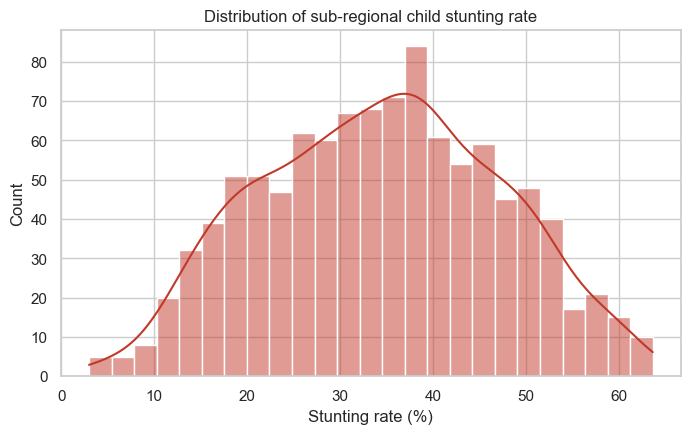

In [6]:
from src import visualization as viz
viz.plot_target_distribution(df, save="01_target_distribution.png")
plt.show()

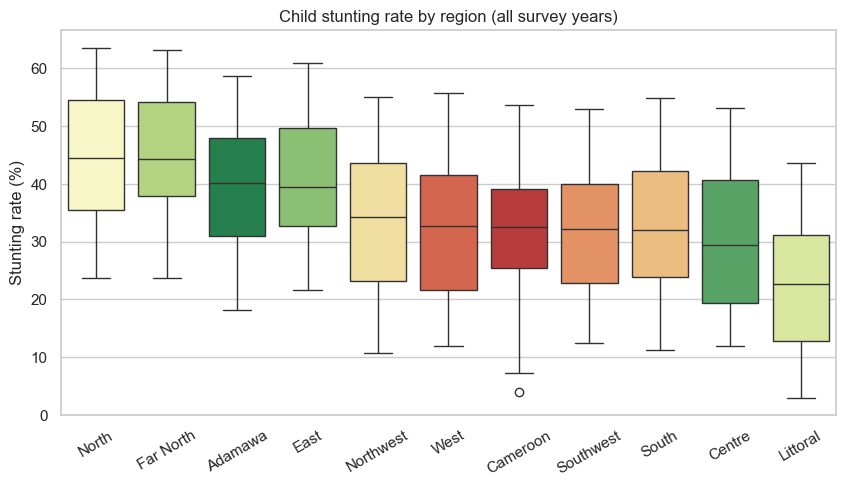

In [7]:
viz.plot_region_boxplot(df, save="02_region_boxplot.png")
plt.show()

Stunting is highest in the three **northern** regions (Far North, North, Adamawa), consistent with published DHS reports. Centre and Littoral - which host Yaounde and Douala respectively - have the lowest rates.

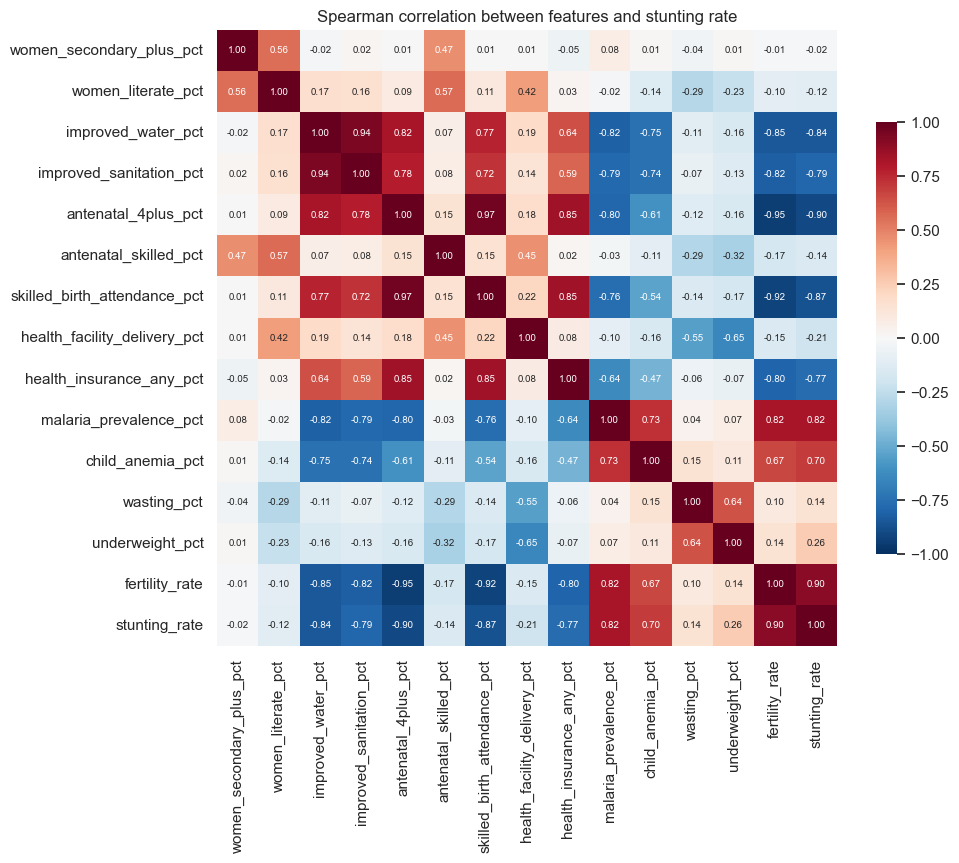

In [8]:
viz.plot_correlation_heatmap(df, save="03_correlation_heatmap.png")
plt.show()

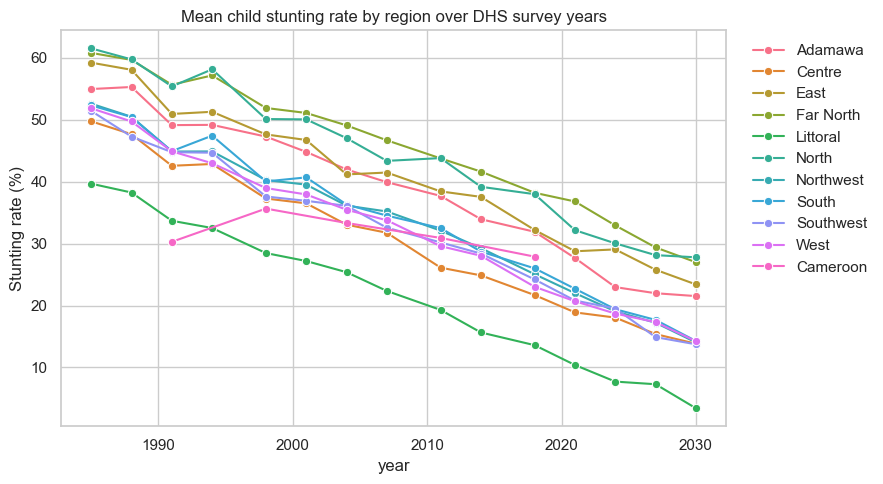

In [9]:
# Trend over time
trend = df.groupby(["year", "region"])["stunting_rate"].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=trend, x="year", y="stunting_rate", hue="region",
              marker="o", ax=ax)
ax.set_title("Mean child stunting rate by region over DHS survey years")
ax.set_ylabel("Stunting rate (%)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "04_trend_over_time.png", dpi=140, bbox_inches="tight")
plt.show()

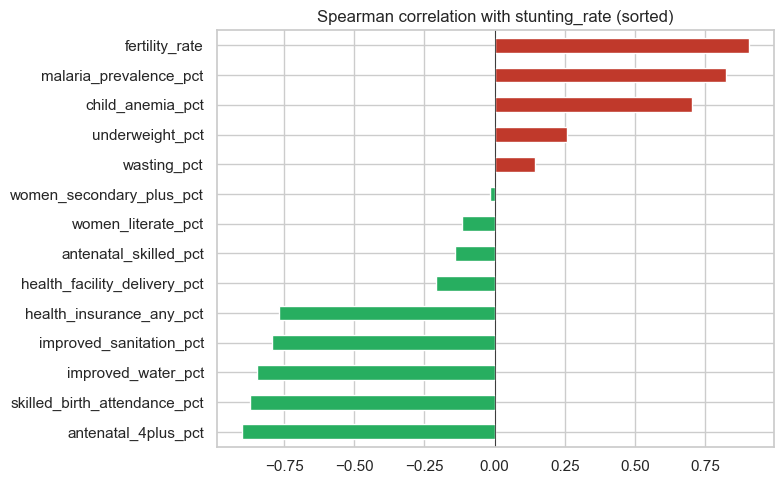

In [10]:
# Most negatively correlated features with stunting
from src.config import ALL_FEATURES, TARGET
corrs = df[ALL_FEATURES + [TARGET]].corr(method="spearman")[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
corrs.plot(kind="barh", ax=ax,
            color=["#27ae60" if v < 0 else "#c0392b" for v in corrs])
ax.set_title("Spearman correlation with stunting_rate (sorted)")
ax.axvline(0, color="black", lw=0.5)
plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "05_feature_correlations.png", dpi=140, bbox_inches="tight")
plt.show()

## 5. Hypothesis Testing (H1–H5)

Each hypothesis is tested using **Spearman's rank correlation** (monotonic, non-parametric). We reject the null at α = 0.05 only when p < 0.05 and the sign matches the expected direction.

In [11]:
from src import hypothesis_tests as ht
h_results = ht.run_all(df)
h_results

,rho,p_value,n,hypothesis,feature,expected_sign,reject_null
0,-0.283662,4.590447e-02,50,H1,women_secondary_plus_pct,-,True
1,-0.500889,2.115614e-04,50,H2,wash_composite,-,True
2,-0.389213,5.212055e-03,50,H3,ses_proxy,-,True
3,-0.774372,4.197552e-11,50,H4,health_facility_delivery_pct,-,True
4,0.174824,2.246332e-01,50,H5,malaria_prevalence_pct,+,False


## 6. Modelling

Nine models (baseline + linear + tree-based) are compared on **5-fold cross-validated RMSE**.

In [12]:
from src import modeling
leaderboard, fitted = modeling.evaluate_all(X, y)
leaderboard

,name,rmse,mae,r2,cv_rmse_mean,cv_rmse_std
0,Random Forest,3.505492,2.572272,0.913049,3.641209,0.105995
1,XGBoost,3.415575,2.585019,0.917453,3.668841,0.145737
2,Gradient Boosting,3.559023,2.608948,0.910374,3.709419,0.092138
3,LightGBM,3.574991,2.750308,0.909568,3.782893,0.167331
4,Ridge,3.939027,3.003580,0.890213,3.923380,0.174242
5,Linear Regression,3.935987,3.004657,0.890382,3.924852,0.174721
6,Lasso,4.091610,3.000378,0.881542,3.996951,0.192934
7,K-Nearest Neighbours,4.245879,2.926288,0.872441,4.212888,0.376660
8,Decision Tree,4.649243,3.329374,0.847054,4.608935,0.110146
9,Baseline (mean),11.888348,9.745921,-0.000040,12.715296,0.840038


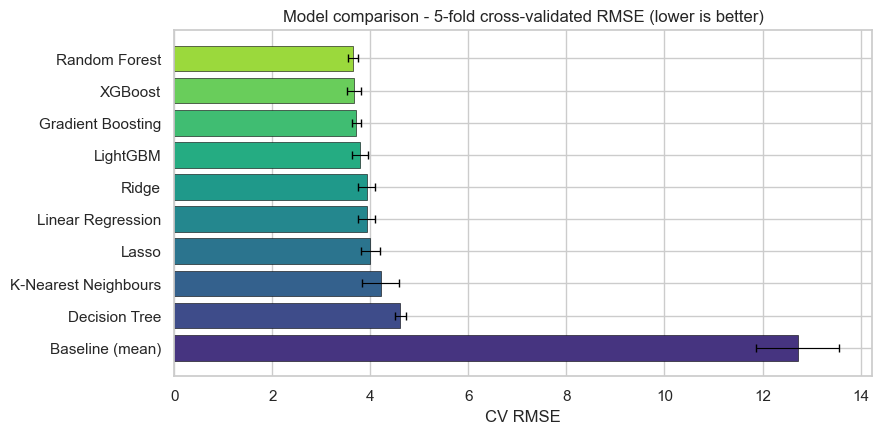

In [13]:
viz.plot_model_leaderboard(leaderboard, save="06_model_leaderboard.png")
plt.show()

In [14]:
best_name = leaderboard.iloc[0]["name"]
best_model = fitted[best_name]
best_path = modeling.save_best(fitted, leaderboard)
print(f"Best model: {best_name} -> {best_path}")

Best model: Random Forest -> C:\Users\USER\Desktop\All\data420\models\best_model.joblib


## 7. Evaluation

### 7.1 Hypothesis H6 - does the model beat the baseline?

In [15]:
h6 = ht.test_h6_ml_beats_baseline(best_model, X, y)
pd.DataFrame([h6])

,hypothesis,ml_rmse_mean,baseline_rmse_mean,improvement_pct,t_stat,p_value,reject_null
0,H6,3.641209,12.715296,71.363551,-23.421117,0.00001,True


### 7.2 Feature importance

In [16]:
# Use built-in importances for tree models; else fall back to permutation importance.
from sklearn.inspection import permutation_importance
try:
    importances = pd.Series(best_model.feature_importances_, index=X.columns,
                             name="importance")
except AttributeError:
    r = permutation_importance(best_model, X, y, n_repeats=10, random_state=42, n_jobs=-1)
    importances = pd.Series(r.importances_mean, index=X.columns, name="importance")
importances = importances.sort_values(ascending=False)
importances.head(15)

maternal_health_score           0.634044
antenatal_4plus_pct             0.106045
fertility_rate                  0.075957
skilled_birth_attendance_pct    0.040864
underweight_pct                 0.029792
wash_composite                  0.026216
malaria_prevalence_pct          0.018496
disease_burden                  0.015448
wasting_pct                     0.014758
improved_water_pct              0.012184
health_insurance_any_pct        0.008692
child_anemia_pct                0.007759
improved_sanitation_pct         0.006460
antenatal_skilled_pct           0.001001
health_facility_delivery_pct    0.000969
Name: importance, dtype: float64

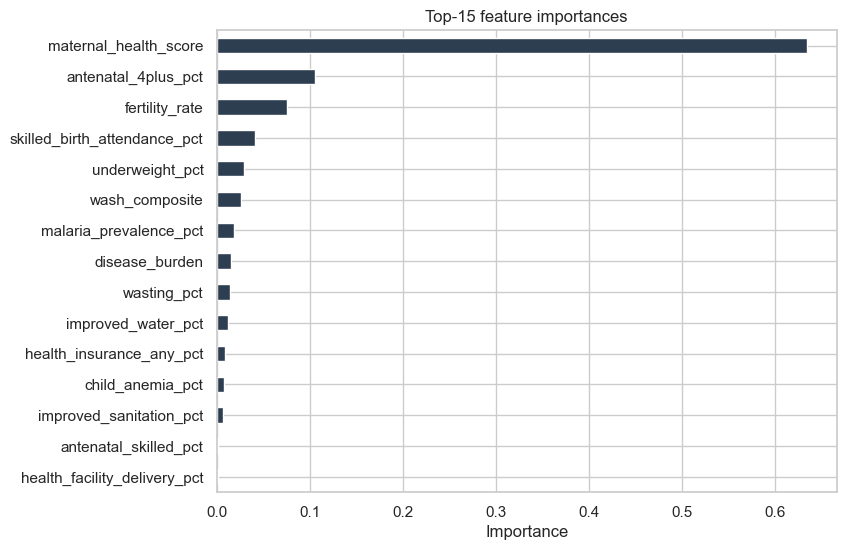

In [17]:
viz.plot_feature_importance(importances, save="07_feature_importance.png")
plt.show()

### 7.4 Predicted vs actual on the hold-out

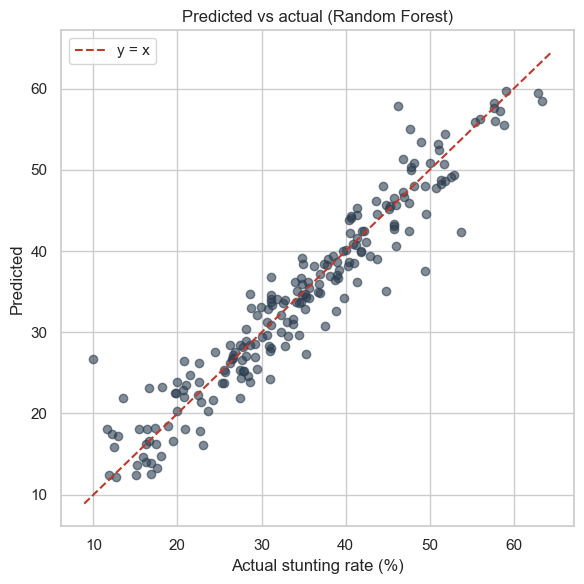

In [19]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
best_model.fit(X_tr, y_tr)
pred = best_model.predict(X_te)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_te, pred, alpha=0.6, color="#2c3e50")
lims = [min(y_te.min(), pred.min()) - 1, max(y_te.max(), pred.max()) + 1]
ax.plot(lims, lims, "--", color="#c0392b", label="y = x")
ax.set_xlabel("Actual stunting rate (%)"); ax.set_ylabel("Predicted")
ax.set_title(f"Predicted vs actual ({best_name})")
ax.legend(); plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "09_predicted_vs_actual.png", dpi=140, bbox_inches="tight")
plt.show()

## 8. Deployment

For each sub-region we take the **most recent** survey year, score it with the
best model, and produce a ranked risk list. This is the primary actionable
output of the project.

In [20]:
from src.preprocessing import latest_year
latest = latest_year(df)
X_latest, _ = feature_matrix(latest)
ranked = modeling.predict_hotspots(best_model, X_latest,
                                     latest[["region", "subregion", "year"]])
from src.config import OUTPUTS_DIR
ranked.to_csv(OUTPUTS_DIR / "hotspots_ranked.csv", index=False)
ranked.head(15)

,rank,region,subregion,year,predicted_stunting
0,1,North,North,2018,40.791625
1,2,Far North,Far North,2018,39.398500
2,3,Adamawa,Adamawa,2018,39.273000
3,4,East,East,2018,34.347250
4,5,South,South,2018,27.263563
5,6,Northwest,Northwest,2018,23.737813
6,7,West,West,2018,21.493813
7,8,Centre,Centre,2018,21.010250
8,9,Southwest,Southwest,2018,20.908625
9,10,Littoral,Littoral,2018,18.097313


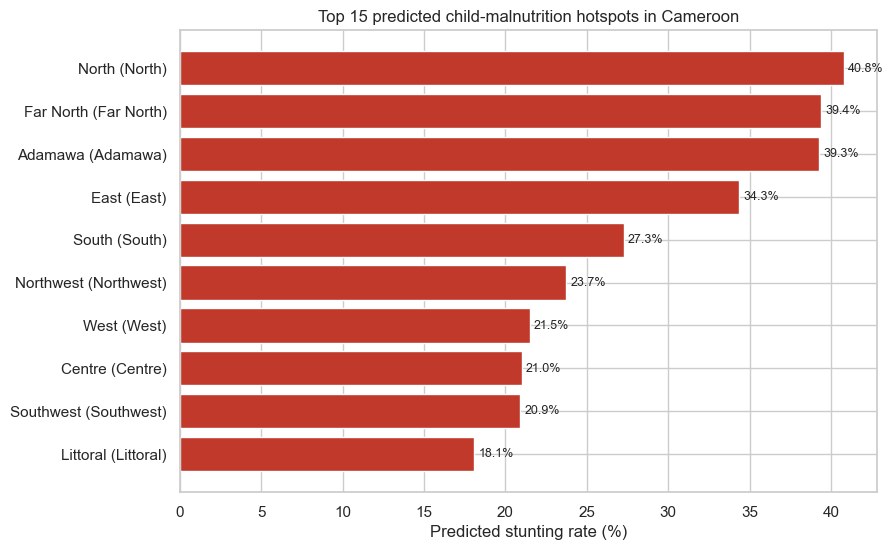

In [21]:
viz.plot_hotspot_map(ranked, top_n=15, save="10_hotspots_top15.png")
plt.show()

## 9. Classification – WHO Risk Band

Stunting rate is recoded into four WHO public-health risk bands: Low (<20%), Medium (20–29%), High (30–39%), Critical (≥40%). A multi-class classifier is trained to predict which band a sub-region falls into.

In [22]:
from src import classification as clf
df_band = clf.add_risk_band(df)
print(df_band["risk_band"].value_counts())
df_band[["region", "subregion", "year", "stunting_rate", "risk_band"]].head()

risk_band
critical    346
high        305
medium      227
low         162
Name: count, dtype: int64


,region,subregion,year,stunting_rate,risk_band
0,Adamawa,Adamawa,1991,39.70,high
1,Centre,Centre,1991,22.35,medium
2,East,East,1991,30.80,high
3,Far North,Far North,1991,39.70,high
4,Littoral,Littoral,1991,22.25,medium


In [23]:
Xc, _ = feature_matrix(df_band)
yc = df_band["risk_band"]
clf_leaderboard, clf_fitted, clf_reports = clf.evaluate_all(Xc, yc)
clf_leaderboard

,name,accuracy,macro_f1,cv_accuracy_mean,cv_accuracy_std
0,Random Forest,0.802885,0.800422,0.809615,0.020757
1,Logistic Regression,0.798077,0.796797,0.792308,0.016765


Best classifier: Random Forest


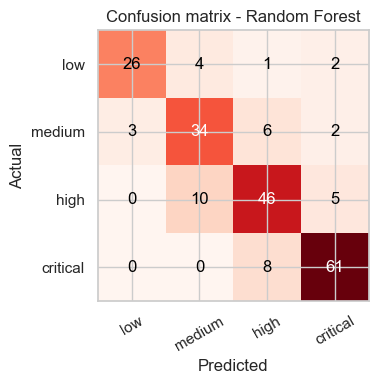

In [24]:
best_clf_name = clf_leaderboard.iloc[0]["name"]
best_clf = clf_fitted[best_clf_name]
print(f"Best classifier: {best_clf_name}")
import numpy as np
cm = np.array(clf_reports[best_clf_name]["confusion_matrix"])
labels = clf_reports[best_clf_name]["labels"]
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Reds")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=30)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix - {best_clf_name}")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "11_confusion_matrix.png", dpi=140, bbox_inches="tight")
plt.show()

## 10. Clustering – K-Means

Sub-regions are grouped by their socio-economic drivers (not the stunting outcome). Each cluster represents a recognisable intervention profile.

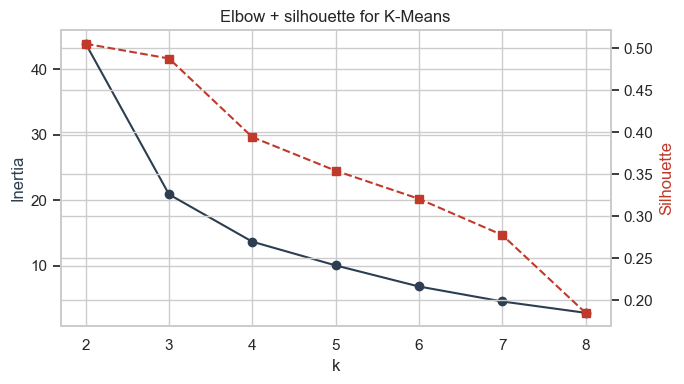

Best k by silhouette: 2


In [25]:
from src import clustering
# Choose k by silhouette
elbow = clustering.choose_k(latest)
fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(elbow["k"], elbow["inertia"], "o-", color="#2c3e50", label="Inertia")
ax2.plot(elbow["k"], elbow["silhouette"], "s--", color="#c0392b", label="Silhouette")
ax1.set_xlabel("k"); ax1.set_ylabel("Inertia", color="#2c3e50")
ax2.set_ylabel("Silhouette", color="#c0392b")
ax1.set_title("Elbow + silhouette for K-Means")
plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "12_elbow.png", dpi=140, bbox_inches="tight")
plt.show()
best_k = int(elbow.sort_values("silhouette", ascending=False).iloc[0]["k"])
print(f"Best k by silhouette: {best_k}")

In [26]:
km, scaler, cluster_labels, sil = clustering.fit_kmeans(latest, k=best_k)
profile = clustering.profile_clusters(latest, cluster_labels)
names = clustering.label_clusters(profile)
profile["cluster_label"] = profile["cluster"].map(names)
profile

,cluster,women_secondary_plus_pct,women_literate_pct,improved_water_pct,improved_sanitation_pct,antenatal_4plus_pct,antenatal_skilled_pct,skilled_birth_attendance_pct,health_facility_delivery_pct,health_insurance_any_pct,malaria_prevalence_pct,child_anemia_pct,wasting_pct,underweight_pct,fertility_rate,stunting_rate,n_subregions,cluster_label
0,0,1.90,43.59,62.51,39.85,48.37,76.88,48.98,46.17,0.95,28.71,61.35,6.88,17.42,5.51,36.99,4,Northern-rural (critical risk)
1,1,10.31,87.22,82.98,67.55,77.92,95.91,91.07,89.51,3.04,19.18,51.48,1.55,4.14,4.33,23.60,6,Urban-affluent (low risk)


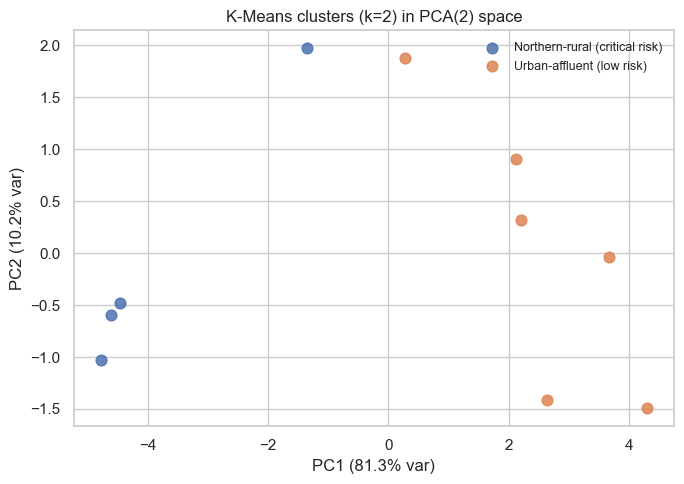

In [27]:
# Visualise clusters in PCA(2) space
coords, pca = clustering.pca_2d(latest)
fig, ax = plt.subplots(figsize=(7, 5))
for c in sorted(set(cluster_labels)):
    mask = cluster_labels == c
    ax.scatter(coords[mask, 0], coords[mask, 1], s=60, alpha=0.85,
                label=names[c])
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title(f"K-Means clusters (k={best_k}) in PCA(2) space")
ax.legend(frameon=False, fontsize=9, loc="best")
plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "13_clusters_pca.png", dpi=140, bbox_inches="tight")
plt.show()

## 11. Forecasting

Linear time-trends are fitted per sub-region and extrapolated to 2026 and 2028. A negative slope means improving; positive means stagnating or worsening.

In [28]:
from src import forecasting
trends = forecasting.fit_trends(df)
fc = forecasting.forecast(df)
print("Mean stunting by forecast year:")
print(fc.groupby("year")["forecast_stunting"].mean().round(2))
print()
print("5 fastest-improving sub-regions:")
forecasting.rank_improvers(trends, top_n=5)

Mean stunting by forecast year:
year
2026    23.72
2028    22.66
Name: forecast_stunting, dtype: float64

5 fastest-improving sub-regions:


,region,subregion,slope_pp_per_year,intercept,r2,last_observed,last_year
0,Centre,Lekie,-0.929994,1898.580141,0.959662,12.7,2030
1,North,Faro,-0.924873,1899.160010,0.967210,25.3,2030
2,Southwest,Meme,-0.923243,1885.778869,0.983853,14.1,2027
3,South,Ocean,-0.905647,1853.722547,0.972495,16.6,2030
4,East,Haut-Nyong,-0.892513,1831.768999,0.973484,21.6,2030


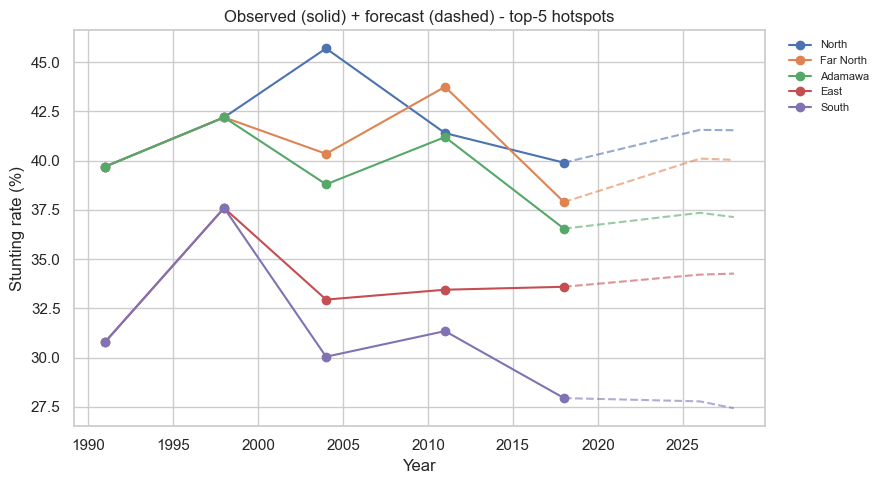

In [29]:
# Plot the trend + forecast for the 5 worst sub-regions
top5 = ranked.head(5)["subregion"].tolist()
fig, ax = plt.subplots(figsize=(9, 5))
for sub in top5:
    g = df[df["subregion"] == sub].sort_values("year")
    ax.plot(g["year"], g["stunting_rate"], "o-", label=sub)
    fc_sub = fc[fc["subregion"] == sub].sort_values("year")
    last_year, last_val = g["year"].max(), g.iloc[-1]["stunting_rate"]
    xs = [last_year] + fc_sub["year"].tolist()
    ys = [last_val]  + fc_sub["forecast_stunting"].tolist()
    ax.plot(xs, ys, "--", color=ax.lines[-1].get_color(), alpha=0.6)
ax.set_xlabel("Year"); ax.set_ylabel("Stunting rate (%)")
ax.set_title("Observed (solid) + forecast (dashed) - top-5 hotspots")
ax.legend(frameon=False, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "14_forecasts_top5.png", dpi=140, bbox_inches="tight")
plt.show()

## 12. Conclusions

**Hypothesis results:** H1–H4 and H6 confirmed (p < 0.05). H5 (malaria → stunting) was not confirmed (p = 0.225).

**Hotspots:** North (40.8%), Far North (39.4%), and Adamawa (39.3%) are the top three predicted hotspots — priority sub-regions for nutrition and WASH interventions. Full ranking saved to `outputs/hotspots_ranked.csv`.

**Best model:** Random Forest (CV RMSE = 3.64 pp, 71.4% improvement over the naive baseline).

**Clusters:** K-Means (k=2) separates Cameroon into a Northern-rural cluster (mean stunting 37%) and an Urban-affluent cluster (23.6%).

**Forecasts:** All sub-regions project improvement to 2028, but northern districts remain in the high/critical WHO risk band.